# IND320 - Project work, part 1 - Dashboard basics

## Github:
## Streamlit:
## Video:

In [86]:
# Import libraries needed
import pandas as pd #handles data
import numpy as np # handles calculations
import seaborn as sns #plotting functions
import matplotlib.pyplot as plt # customize plot

# loading the reservior.cvs file using pandas
data = pd.read_csv("reservoirs.csv")

# Shows information about the dataset; dtype, columns, non-NA, memory usage
data.info()
# Prints how many rows and columns in dataset
print(f"\n Number of columns and rows in reservior.cvs: {data.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dato_Id                   14877 non-null  object 
 1   omrType                   14877 non-null  object 
 2   omrnr                     14877 non-null  int64  
 3   iso_aar                   14877 non-null  int64  
 4   iso_uke                   14877 non-null  int64  
 5   fyllingsgrad              14877 non-null  float64
 6   kapasitet_TWh             14877 non-null  float64
 7   fylling_TWh               14877 non-null  float64
 8   neste_Publiseringsdato    14877 non-null  object 
 9   fyllingsgrad_forrige_uke  14877 non-null  float64
 10  endring_fyllingsgrad      14877 non-null  float64
dtypes: float64(5), int64(3), object(3)
memory usage: 1.2+ MB

 Number of columns and rows in reservior.cvs: (14877, 11)


The dataset contains 14877 rows and 11 columns (with no missing value) that consist of objects, integers and floats. 

In [89]:
#Shows column names in the dataset
print("\nColumns in reservior.cvs:")
print(data.columns)

#Shows the first five rows. Used to inspect the dataset
data.head()


Columns in reservior.cvs:
Index(['dato_Id', 'omrType', 'omrnr', 'iso_aar', 'iso_uke', 'fyllingsgrad',
       'kapasitet_TWh', 'fylling_TWh', 'neste_Publiseringsdato',
       'fyllingsgrad_forrige_uke', 'endring_fyllingsgrad'],
      dtype='object')


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


- Some of the values display more than two decimals.
- "neste_Publiseringsdato" shows date and time and has 0001-01-01 on multiple rows
- "dato_Id" needs to be converted to a date instead of object

In [92]:
# Converts to datetime
data["dato_Id"] = pd.to_datetime(data["dato_Id"], errors="coerce")

#Missing values converted to NaT and converts to datetime
data["neste_Publiseringsdato"] = pd.to_datetime(
    data["neste_Publiseringsdato"],
    errors="coerce",
    format="mixed"
)

#Prints out the first few rowa to check
print(data.head())

#Prints out the number of dates missing
print(data["neste_Publiseringsdato"].notna().sum())


     dato_Id omrType  omrnr  iso_aar  iso_uke  fyllingsgrad  kapasitet_TWh  \
0 1995-09-03      EL      4     1995       35      0.944721      21.079208   
1 2020-11-15      EL      1     2020       46      0.974361       6.003264   
2 2011-08-28      EL      4     2011       34      0.786499      21.079208   
3 1998-07-05      EL      3     1998       27      0.793969       8.920932   
4 2011-03-27      EL      4     2011       12      0.300820      21.079208   

   fylling_TWh neste_Publiseringsdato  fyllingsgrad_forrige_uke  \
0    19.913979                    NaT                  0.936888   
1     5.849344    2020-11-25 13:00:00                  0.997406   
2    16.578772                    NaT                  0.787193   
3     7.082947                    NaT                  0.733812   
4     6.341054                    NaT                  0.311122   

   endring_fyllingsgrad  
0              0.007833  
1             -0.023046  
2             -0.000694  
3              0.060157 

In [94]:
#Renames columns to english variables 
df = data.rename ( columns={'dato_Id': 'Date', 'omrType': 'Area_type', 'omrnr': 'Area_number', 'iso_aar':' Iso_yr', 'iso_uke': 'Iso_week', 'fyllingsgrad': 'Fill_lvl', 'kapasitet_TWh': 'Capacity_TWh', 'fylling_TWh': 'Fill_TWh', 'neste_Publiseringsdato': 'Nxt_pubDate', 'fyllingsgrad_forrige_uke': 'Fill_lvl_Lstweek', 'endring_fyllingsgrad': 'Diff_Fill_lvl'})

#new column combining area type and area number
df["Area"] = df["Area_type"] + df["Area_number"].astype(str)

#Sorted data by their area and date
df = df.sort_values(["Area", "Date"]).reset_index(drop=True)

#Shows data types of the columns
df.dtypes

Date                datetime64[ns]
Area_type                   object
Area_number                  int64
 Iso_yr                      int64
Iso_week                     int64
Fill_lvl                   float64
Capacity_TWh               float64
Fill_TWh                   float64
Nxt_pubDate         datetime64[ns]
Fill_lvl_Lstweek           float64
Diff_Fill_lvl              float64
Area                        object
dtype: object

In [96]:
#Shows first five rows
display(df.head())

# Number of rows and date range for each areas
display(df.groupby("Area")["Date"].agg(rows="count", first="min", last="max"))

,Date,Area_type,Area_number,Iso_yr,Iso_week,Fill_lvl,Capacity_TWh,Fill_TWh,Nxt_pubDate,Fill_lvl_Lstweek,Diff_Fill_lvl,Area
0,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,NaT,0.734888,-0.113421,EL1
1,1995-01-15,EL,1,1995,2,0.583100,6.003264,3.500502,NaT,0.621467,-0.038367,EL1
2,1995-01-22,EL,1,1995,3,0.550604,6.003264,3.305419,NaT,0.583100,-0.032496,EL1
3,1995-01-29,EL,1,1995,4,0.508440,6.003264,3.052297,NaT,0.550604,-0.042164,EL1
4,1995-02-05,EL,1,1995,5,0.469223,6.003264,2.816870,NaT,0.508440,-0.039217,EL1


,rows,first,last
Area,,,
EL1,1653,1995-01-08,2026-09-06
EL2,1653,1995-01-08,2026-09-06
EL3,1653,1995-01-08,2026-09-06
EL4,1653,1995-01-08,2026-09-06
EL5,1653,1995-01-08,2026-09-06
NO0,1653,1995-01-08,2026-09-06
VASS1,1653,1995-01-08,2026-09-06
VASS2,1653,1995-01-08,2026-09-06
VASS3,1653,1995-01-08,2026-09-06


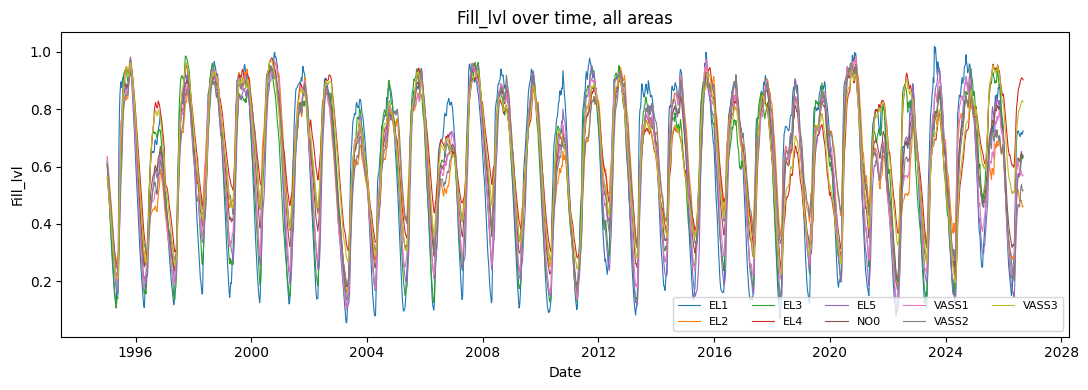

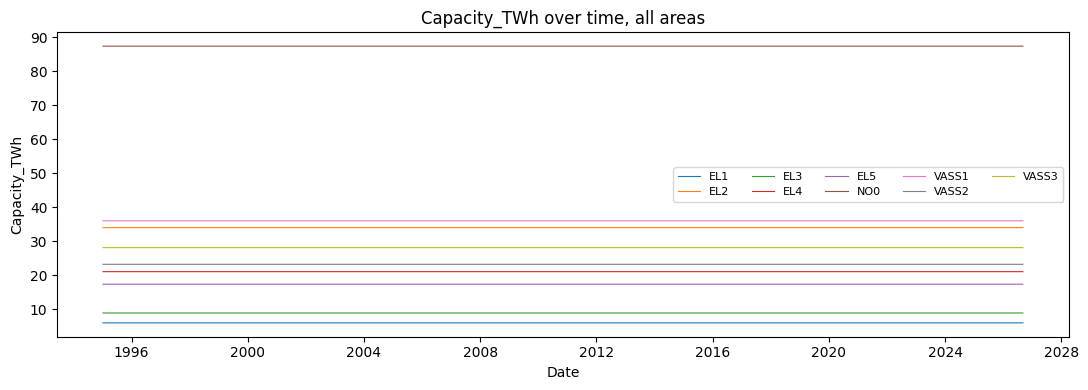

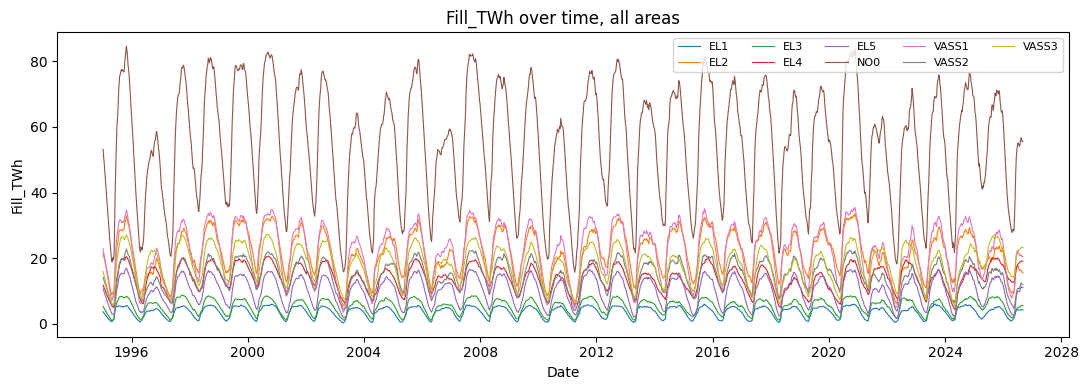

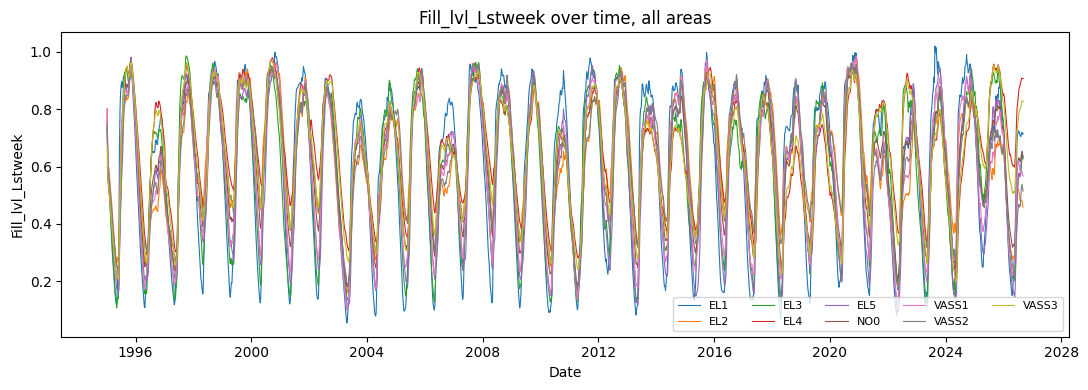

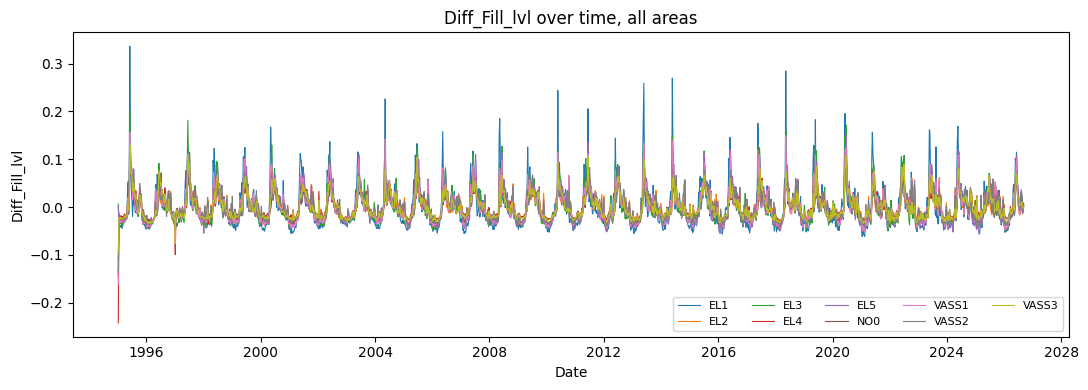

In [98]:
#columns with numerical values
number_cols = ["Fill_lvl", "Capacity_TWh", "Fill_TWh", "Fill_lvl_Lstweek", "Diff_Fill_lvl"]

#Create one figure for each numerical column
for col in number_cols:
    fig, ax = plt.subplots(figsize=(11, 4))
    
      #Plot one line for each area
    for area, g in df.groupby("Area"):
        ax.plot(g["Date"], g[col], label=area, linewidth=0.8)
        
# Adds title and axis
    ax.set_title(f"{col} over time, all areas") 
    ax.set_xlabel("Date") 
    ax.set_ylabel(col) #adds a legend
    ax.legend(ncol=5, fontsize=8)    # adjusts the plot             
    plt.tight_layout()

    #Shows the plot
    plt.show()


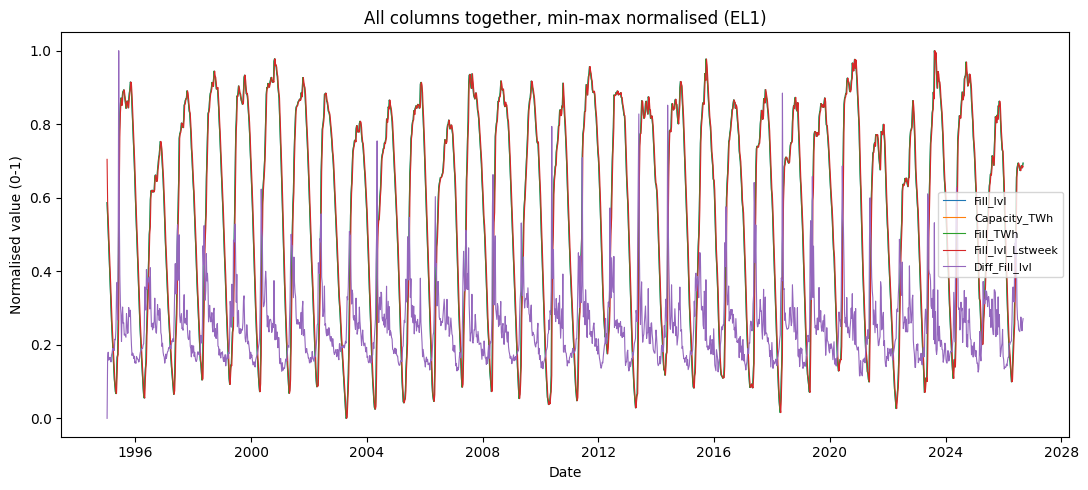

In [99]:
#Selects a area for the combined plot
area = "EL1"
g = df[df["Area"] == area]

#the values range between 0 to 1, formula: (value - min) / (max - min)
norm = (g[number_cols] - g[number_cols].min()) / (g[number_cols].max() - g[number_cols].min())

# Plots all columns in the same figure
fig, ax = plt.subplots(figsize=(11, 5))

#Plot each column as a separate line
for col in number_cols:
    ax.plot(g["Date"], norm[col], label=col, linewidth=0.8)
#title and axis names
ax.set_title(f"All columns together, min-max normalised ({area})")
ax.set_xlabel("Date")
ax.set_ylabel("Normalised value (0-1)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Log

## Jupyter Notebook

Datasettet «reservoirs.csv» ble lastet opp ved hjelp av Pandas. Datasettet besto av 14 877 rader og 11 kolonner med tre ulike datatyper: float64 (5), int64 (3) og object (3). De numeriske kolonnene hadde svært ulike verdier, og måtte dermed skaleres for å kunne sammenlignes. Jeg brukte data.head()for å vise de fem første radene og undersøke datasettet, og la merke til at kolonnen «neste_Publiseringsdato» inneholdt både datoer og klokkeslett. Siden tekst ikke kan plottes, har jeg kun plottet kolonnene med tall – både hver for seg og samlet – slik oppgaven spør. Kolonnene fikk engelske navn ved hjelp av data.rename(), «date»-kolonnen ble konvertert til  datetime-format, alle tomme verdier av typen «0001-01-01» ble endret til manglende verdier (missing values), og det ble laget  en ny kolonne kalt «Area». Det viste seg at bare 3 555 av de 14 877 radene hadde en gyldig dato. Å plotte alle kolonnene samlet krevde at  tallene måtte skaleres til verdier mellom 0 og 1. Kolonnene "area_type" og "area_number" ble slått sammen til en ny kolonne kalt «Area»slik at de kunne gruppere dataene etter område og sammenlignes i samme plot.



## KI-Erklæring
I denne oppgaven har det blitt benyttet KI-verktøyet ChatGPT og Claude i tråd med NMBUs retningslinjer 
for K3. Mer spesifikt, ble det brukt for å kontrollere egen kode ved å spørre om koden var korrekt 
og om den oppfylte kravene i oppgaven. Når det ble identifisert feil, ble det generert 
utdypende forslag og forklaringer til hvordan det kunne rettes. Forslagene ble brukt til å 
korrigere, forstå og forbedre koden